In [219]:
# Importando Librerias
import numpy  as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

from sklearn.model_selection         import train_test_split
from sklearn.linear_model            import LogisticRegression
from sklearn.metrics                 import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer

In [220]:
# Cargar Datos
df = pd.read_csv('mail_data.csv')

# mirar cuantos datos, hay de cada categoria ( Eliminar dataset desbalanceado )
df_ham  = df[df['Category'] == 'ham']
df_spam = df[df['Category'] == 'spam']

print('Ham: ', df_ham.shape)
print('Spam: ', df_spam.shape)

# solo tomar 900 Ham
df_ham = df_ham.sample(n=900, random_state=42)

print('Ham: ', df_ham.shape)

df = pd.concat([df_ham, df_spam], axis=0)
print('Total: ', df.shape)

df.head()

Ham:  (4825, 2)
Spam:  (747, 2)
Ham:  (900, 2)
Total:  (1647, 2)


,Category,Message
3714,ham,If i not meeting ü all rite then i'll go home ...
1311,ham,"I.ll always be there, even if its just in spir..."
548,ham,"Sorry that took so long, omw now"
1324,ham,I thk 50 shd be ok he said plus minus 10.. Did...
3184,ham,Dunno i juz askin cos i got a card got 20% off...


In [221]:
print(df.shape)

(1647, 2)


In [222]:
# remplazar los valores nulones por un ''
df = df.where((pd.notnull(df)),'')

In [223]:
df.dtypes

,0
Category,object
Message,object


In [224]:
# Spam 0 y Ham 1 (no spam)
df.loc[df['Category'] == 'spam', 'Category',] = 0
df.loc[df['Category'] == 'ham', 'Category',] = 1

In [225]:
df.head(10)

,Category,Message
3714,1,If i not meeting ü all rite then i'll go home ...
1311,1,"I.ll always be there, even if its just in spir..."
548,1,"Sorry that took so long, omw now"
1324,1,I thk 50 shd be ok he said plus minus 10.. Did...
3184,1,Dunno i juz askin cos i got a card got 20% off...
1075,1,Aight ill get on fb in a couple minutes
1412,1,somewhere out there beneath the pale moon ligh...
3043,1,Slaaaaave ! Where are you ? Must I summon you ...
14,1,I HAVE A DATE ON SUNDAY WITH WILL!!
5097,1,Sorry about that this is my mates phone and i ...


In [226]:
# X (messages), Y(Category)
x = df['Message']
y = df['Category']

In [227]:
print(x)

3714    If i not meeting ü all rite then i'll go home ...
1311    I.ll always be there, even if its just in spir...
548                      Sorry that took so long, omw now
1324    I thk 50 shd be ok he said plus minus 10.. Did...
3184    Dunno i juz askin cos i got a card got 20% off...
                              ...                        
5537    Want explicit SEX in 30 secs? Ring 02073162414...
5540    ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547    Had your contract mobile 11 Mnths? Latest Moto...
5566    REMINDER FROM O2: To get 2.50 pounds free call...
5567    This is the 2nd time we have tried 2 contact u...
Name: Message, Length: 1647, dtype: object


In [228]:
print(y)

3714    1
1311    1
548     1
1324    1
3184    1
       ..
5537    0
5540    0
5547    0
5566    0
5567    0
Name: Category, Length: 1647, dtype: object


In [229]:
# 80% entrenamiento, 20% test
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=3)

print(x.shape)
print(X_train.shape)
print(X_test.shape)

(1647,)
(1317,)
(330,)


In [230]:
# Pasar los textos a vectores numericos
feature_extraction = TfidfVectorizer(min_df=1, stop_words='english', lowercase=True)

X_train_features = feature_extraction.fit_transform(X_train)
X_test_features = feature_extraction.transform(X_test)

Y_train = Y_train.astype('int')
Y_test = Y_test.astype('int')


In [231]:
print(X_train_features)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13768 stored elements and shape (1317, 4085)>
  Coords	Values
  (0, 3240)	0.1279277966104307
  (0, 2322)	0.21508738656235812
  (0, 3807)	0.11428434969732475
  (0, 2353)	0.2384110131132669
  (0, 2598)	0.2384110131132669
  (0, 2156)	0.22873083347546408
  (0, 1952)	0.21508738656235812
  (0, 3744)	0.11400510427427733
  (0, 2350)	0.3008410887889936
  (0, 2596)	0.2384110131132669
  (0, 2597)	0.2384110131132669
  (0, 2528)	0.2384110131132669
  (0, 722)	0.2384110131132669
  (0, 1601)	0.20990038877935446
  (0, 24)	0.2384110131132669
  (0, 635)	0.21508738656235812
  (0, 4050)	0.22873083347546408
  (0, 2869)	0.2212223028140657
  (0, 3751)	0.2384110131132669
  (0, 730)	0.2384110131132669
  (0, 305)	0.13817351696166688
  (1, 1904)	0.3933170008834677
  (1, 1824)	0.4723064347493285
  (1, 3819)	0.4467409765203943
  (1, 1520)	0.4723064347493285
  :	:
  (1315, 1334)	0.22879488358426978
  (1315, 2446)	0.23329626136930104
  (1315, 630)	0.198277

In [232]:
# Entrenar el modelo
model = LogisticRegression()
model.fit(X_train_features, Y_train)

LogisticRegression()

In [233]:
# Predicciones en los datos

prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(Y_train, prediction_on_training_data)

print('Accuracy on training data : ', accuracy_on_training_data)

Accuracy on training data :  0.979498861047836


In [234]:
# Predicciones en los datos de test
predictions = model.predict(X_test_features)
accuracy = accuracy_score(Y_test, predictions)

print('Accuracy on test data : ', accuracy)

Accuracy on test data :  0.9727272727272728


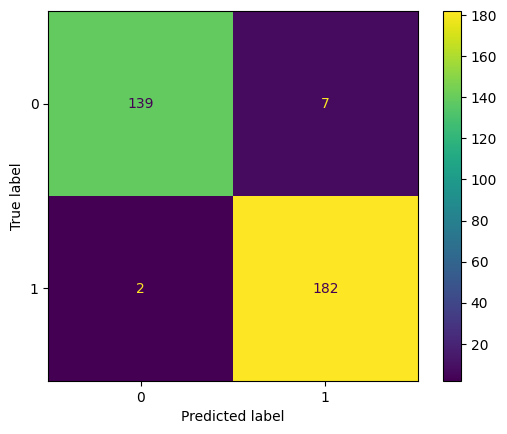

In [235]:
# Matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(Y_test, predictions), display_labels=model.classes_)
disp.plot()

In [236]:
# Gmails ejemplos

input_mails = [
    "URGENT! You've won $10,000,000! Click here to claim your prize NOW! Limited time offer. Don't miss this once-in-a-lifetime opportunity!!!",
    "Dear user, your account has been successfully updated. Thank you for using our service.",
    "Meeting tomorrow at 10am to discuss the quarterly report. Please be on time.",
    "Congratulations! You've been selected for a free gift. Just pay for shipping!"
]

# Vectorizar los ejemplos de gmails
imputs_data_features = feature_extraction.transform(input_mails)

# print(imputs_data_features)

# Hacer prediciones
predictions = model.predict(imputs_data_features)
print(predictions)

[0 0 1 0]


In [237]:
for i, prediction in enumerate(predictions):
    if prediction == 0:
        print(f"Gmail {i+1}: Spam")
    else:
        print(f"Gmail {i+1}: No Spam")

Gmail 1: Spam
Gmail 2: Spam
Gmail 3: No Spam
Gmail 4: Spam


In [238]:
# Save model and vectorizer
joblib.dump(model, 'spam_classifier_model.pkl')
joblib.dump(feature_extraction, 'tfidf_vectorizer.pkl')

['tfidf_vectorizer.pkl']